# Yield Prediction Model Selection and Evaluation

This notebook compares baseline, candidate, and tuned regression models for yield prediction using the processed train/test split.

## Workflow

1. Load the processed yield train and test files.
2. Benchmark baseline and candidate regressors with 5-fold cross-validation on the training set.
3. Tune the top two models with 3-fold RandomizedSearchCV.
4. Compare the tuned models and evaluate the final choice on the holdout test set.

In [1]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data' / 'processed'
RESULTS_DIR = ROOT / 'outputs'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / 'yield_train_raw.csv'
TEST_PATH = DATA_DIR / 'yield_test_raw.csv'

In [2]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

X_train = train_df.drop(columns=['Yield'])
y_train = train_df['Yield']
X_test = test_df.drop(columns=['Yield'])
y_test = test_df['Yield']

display(X_train.head())
print('Training shape:', X_train.shape, 'Test shape:', X_test.shape)
print('Target summary:')
display(y_train.describe().to_frame('train_yield'))

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide
0,Groundnut,2011,Kharif,Goa,357.0,1022.0,2698.2,59804.64,117.81
1,Barley,2007,Kharif,Delhi,75.0,196.0,677.5,10005.00,12.00
2,Moth,1999,Whole Year,Uttar Pradesh,204.0,84.0,883.4,21650.52,55.08
3,Barley,2014,Rabi,Uttarakhand,21054.0,24800.0,1287.4,3178311.84,6947.82
4,Cotton(lint),2002,Kharif,Madhya Pradesh,185695.0,304705.5,800.8,24727596.07,49569.20


Training shape: (15751, 9) Test shape: (3938, 9)
Target summary:


,train_yield
count,15751.000000
mean,1.788485
std,1.654207
min,0.000000
25%,0.600000
50%,1.031143
75%,2.403716
max,5.072222


In [3]:
categorical_features = ['Crop', 'Season', 'State']
numeric_features = [col for col in X_train.columns if col not in categorical_features]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def build_pipeline(model, use_preprocessor=True):
    if use_preprocessor:
        return Pipeline([('preprocessor', preprocessor), ('model', model)])
    return Pipeline([('model', model)])

def evaluate_model(name, estimator):
    start = time.perf_counter()
    scores = cross_validate(
        estimator,
        X_train,
        y_train,
        cv=cv,
        scoring={
            'r2': 'r2',
            'mae': 'neg_mean_absolute_error',
            'rmse': 'neg_root_mean_squared_error',
        },
        n_jobs=-1,
        return_train_score=False,
    )
    elapsed = time.perf_counter() - start
    return {
        'model': name,
        'r2': scores['test_r2'].mean(),
        'mae': -scores['test_mae'].mean(),
        'rmse': -scores['test_rmse'].mean(),
        'fit_time_mean_sec': scores['fit_time'].mean(),
        'cv_elapsed_sec': elapsed,
    }

In [4]:
from tqdm.auto import tqdm

models = {
    'DummyRegressor': build_pipeline(DummyRegressor(strategy='median')),
    'LinearRegression': build_pipeline(LinearRegression()),
    'RandomForestRegressor': build_pipeline(RandomForestRegressor(n_estimators=400, random_state=RANDOM_STATE, n_jobs=1)),
    'XGBRegressor': build_pipeline(XGBRegressor(
        objective='reg:squarederror',
        n_estimators=400,
        learning_rate=0.08,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )),
    'SVR_rbf': build_pipeline(SVR(kernel='rbf', C=10, gamma='scale')),
    'ExtraTreesRegressor': build_pipeline(ExtraTreesRegressor(n_estimators=500, random_state=RANDOM_STATE, n_jobs=1)),
    'GradientBoostingRegressor': build_pipeline(GradientBoostingRegressor(random_state=RANDOM_STATE)),
}

baseline_results = []
for name, estimator in tqdm(models.items(), desc='Baseline Models', ncols=90):
    baseline_results.append(evaluate_model(name, estimator))

results_df = pd.DataFrame(baseline_results).sort_values(['r2', 'mae'], ascending=[False, True]).reset_index(drop=True)
display(results_df)
results_df.to_csv(RESULTS_DIR / 'yield_model_selection_cv_results.csv', index=False)

Baseline Models:   0%|                                              | 0/7 [00:00<?, ?it/s]

,model,r2,mae,rmse,fit_time_mean_sec,cv_elapsed_sec
0,XGBRegressor,0.971684,0.153310,0.278164,1.636770,4.649682
1,RandomForestRegressor,0.961035,0.144004,0.325983,81.550977,85.947129
2,ExtraTreesRegressor,0.956338,0.142487,0.345329,76.729569,77.858699
3,SVR_rbf,0.944435,0.190593,0.389322,20.912599,29.211458
4,GradientBoostingRegressor,0.877119,0.402515,0.579358,5.111346,5.261221
5,LinearRegression,0.790250,0.505861,0.757121,0.146269,2.789658
6,DummyRegressor,-0.210229,1.195004,1.819248,0.043850,4.007791


## Hyperparameter Tuning

The next cell tunes the two strongest models with 3-fold RandomizedSearchCV.

In [5]:
import time
from tqdm.auto import tqdm
from sklearn.model_selection import cross_val_score, ParameterSampler

def manual_random_search(name, base_estimator, param_distributions, n_iter, X, y, cv):
    sampler = ParameterSampler(param_distributions, n_iter=n_iter, random_state=RANDOM_STATE)
    best_score, best_params, results = -float('inf'), {}, []
    
    print(f'\n[{name}] {n_iter} param combos x {cv.n_splits} folds', flush=True)
    bar = tqdm(sampler, total=n_iter, desc=name, unit='combo', ncols=90)
    for params in bar:
        est = base_estimator.set_params(**params)
        t0 = time.perf_counter()
        # n_jobs=-1 handles parallel folds safely because models are n_jobs=1
        scores = cross_val_score(est, X, y, cv=cv, scoring='r2', n_jobs=-1)
        elapsed = time.perf_counter() - t0
        mean_score = scores.mean()
        
        short = {k.split('__')[-1]: v for k, v in params.items()}
        bar.set_postfix({'r2': f'{mean_score:.4f}', 'best': f'{best_score:.4f}', 's': f'{elapsed:.0f}'})
        tqdm.write(f'  {short}  ->  r2={mean_score:.4f}  [{elapsed:.1f}s]', end='\n')
        
        results.append({'params': params, 'mean_r2': mean_score, 'std_r2': scores.std(), 'elapsed': elapsed})
        if mean_score > best_score:
            best_score, best_params = mean_score, params
            
    bar.close()
    print(f'\nBest {name} params: {best_params}', flush=True)
    print(f'Best {name} CV R2: {best_score:.4f}', flush=True)
    return best_params, best_score, results

cv3 = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# --- RandomForest Tuning ---
rf_pipe = build_pipeline(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1))
rf_distributions = {
    'model__n_estimators': [300, 500, 700, 900],
    'model__max_depth': [None, 12, 18, 24],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', 0.8],
}
rf_best_params, rf_best_score, rf_results = manual_random_search(
    'RandomForest', rf_pipe, rf_distributions, n_iter=15, X=X_train, y=y_train, cv=cv3
)

# --- XGBoost Tuning ---
xgb_pipe = build_pipeline(XGBRegressor(
    objective='reg:squarederror',
    random_state=RANDOM_STATE,
    n_jobs=1,
))
xgb_distributions = {
    'model__n_estimators': [200, 300, 500, 700],
    'model__max_depth': [4, 6, 8, 10],
    'model__learning_rate': [0.03, 0.05, 0.08, 0.1],
    'model__subsample': [0.75, 0.85, 0.9, 1.0],
    'model__colsample_bytree': [0.75, 0.85, 0.9, 1.0],
    'model__min_child_weight': [1, 3, 5, 7],
    'model__reg_alpha': [0.0, 0.1, 0.5],
    'model__reg_lambda': [1.0, 1.5, 2.0],
}
xgb_best_params, xgb_best_score, xgb_results = manual_random_search(
    'XGBoost', xgb_pipe, xgb_distributions, n_iter=15, X=X_train, y=y_train, cv=cv3
)



[RandomForest] 15 param combos x 3 folds


RandomForest:   0%|                                             | 0/15 [00:00<?, ?combo/s]

  {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 0.8, 'max_depth': 24}  ->  r2=0.9477  [31.6s]
  {'n_estimators': 900, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.8, 'max_depth': None}  ->  r2=0.9615  [121.1s]
  {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.8, 'max_depth': 12}  ->  r2=0.8818  [20.6s]
  {'n_estimators': 700, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None}  ->  r2=0.8991  [13.3s]
  {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 24}  ->  r2=0.8325  [3.8s]
  {'n_estimators': 900, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 18}  ->  r2=0.8022  [10.1s]
  {'n_estimators': 700, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.8, 'max_depth': 24}  ->  r2=0.9540  [73.8s]
  {'n_estimators': 700, 'min_samples_split': 10, 'min_

XGBoost:   0%|                                                  | 0/15 [00:00<?, ?combo/s]

  {'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 0.5, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 10, 'learning_rate': 0.08, 'colsample_bytree': 0.85}  ->  r2=0.9704  [6.3s]
  {'subsample': 0.75, 'reg_lambda': 2.0, 'reg_alpha': 0.5, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 0.75}  ->  r2=0.9667  [4.6s]
  {'subsample': 0.75, 'reg_lambda': 1.5, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 10, 'learning_rate': 0.03, 'colsample_bytree': 0.85}  ->  r2=0.9679  [4.3s]
  {'subsample': 0.85, 'reg_lambda': 1.0, 'reg_alpha': 0.0, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 8, 'learning_rate': 0.08, 'colsample_bytree': 0.75}  ->  r2=0.9713  [3.8s]
  {'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0.0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.85}  ->  r2=0.9650  [1.6s]
  {'subsample': 0.9, 'reg_lambda': 1.0, 'reg_a

In [8]:
rf_tuned = build_pipeline(RandomForestRegressor(**{k.split('__')[-1]: v for k, v in rf_best_params.items()}, random_state=RANDOM_STATE, n_jobs=1))
xgb_tuned = build_pipeline(XGBRegressor(**{k.split('__')[-1]: v for k, v in xgb_best_params.items()}, objective='reg:squarederror', random_state=RANDOM_STATE, n_jobs=1))

tuned_candidates = {
    'RandomForest_tuned': rf_tuned,
    'XGBoost_tuned': xgb_tuned,
}

tuned_results = []
for name, estimator in tuned_candidates.items():
    tuned_results.append(evaluate_model(name, estimator))

tuned_df = pd.DataFrame(tuned_results).sort_values(['r2', 'mae'], ascending=[False, True]).reset_index(drop=True)
display(tuned_df)
tuned_df.to_csv(RESULTS_DIR / 'yield_model_selection_tuned_results.csv', index=False)

best_row = tuned_df.iloc[0]
best_model_name = best_row['model']
best_model = tuned_candidates[best_model_name]
print(f'Chosen model: {best_model_name}')
print(f"Cross-validated R2: {best_row['r2']:.4f}")
print(f"Cross-validated MAE: {best_row['mae']:.4f}")
print(f"Cross-validated RMSE: {best_row['rmse']:.4f}")


,model,r2,mae,rmse,fit_time_mean_sec,cv_elapsed_sec
0,XGBoost_tuned,0.974664,0.137344,0.263168,2.941061,7.030679
1,RandomForest_tuned,0.964095,0.141559,0.312854,155.055786,162.093087


Chosen model: XGBoost_tuned
Cross-validated R2: 0.9747
Cross-validated MAE: 0.1373
Cross-validated RMSE: 0.2632


Holdout test R2: 0.9786
Holdout test MAE: 0.1277
Holdout test RMSE: 0.2405


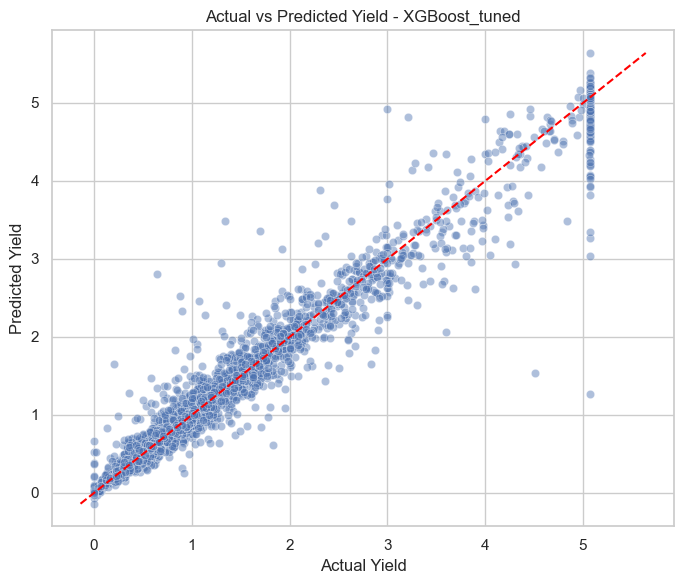

In [9]:
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
test_r2 = r2_score(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = mean_squared_error(y_test, y_pred) ** 0.5

print('Holdout test R2:', round(test_r2, 4))
print('Holdout test MAE:', round(test_mae, 4))
print('Holdout test RMSE:', round(test_rmse, 4))

plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.45)
max_value = max(y_test.max(), y_pred.max())
min_value = min(y_test.min(), y_pred.min())
plt.plot([min_value, max_value], [min_value, max_value], '--', color='red')
plt.title(f'Actual vs Predicted Yield - {best_model_name}')
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
plt.tight_layout()
plt.show()

## Final Selection Note

The notebook selects the tuned model with the highest cross-validated R², then checks MAE and RMSE as secondary criteria. If the top two are close, prefer the faster and simpler model for deployment.